In [16]:
# ----- Paste into your notebook -----
import numpy as np
from nilearn import datasets, plotting, surface
import nibabel as nib
import pandas as pd

# ---- Replace/confirm: your SHAP vector and region_keys ----
# shap_vals should be shape (68,) if it truly matches the 34+34 DK regions
# Example: shap_vals = np.load("shap_vals.npy")
# If you already have shap_vals in the notebook, this will use it.
# region_shap_summary_all_folds_reps.csv
shap_dir = "shap_gcn_results"
shap_df = pd.read_csv(f"{shap_dir}/region_shap_summary_all_folds_reps.csv")
# If the SHAP values are in the second column:
shap_vals = shap_df.iloc[:, 1].values  # adjust column index if needed
shap_vals = np.asarray(shap_vals)  # ensure numpy array

region_keys = shap_df['region'].tolist()  # adjust column name if needed

print("expected region_keys length:", len(region_keys))
print("shap_vals.shape:", shap_vals.shape)


expected region_keys length: 68
shap_vals.shape: (68,)


In [17]:
# ---- Quick shape check ----
if shap_vals.ndim != 1:
    raise ValueError("shap_vals must be a 1-D vector (one value per region).")
if shap_vals.shape[0] != len(region_keys):
    print("WARNING: shap_vals length != number of region_keys.")
    print("  len(shap_vals) =", shap_vals.shape[0], "len(region_keys) =", len(region_keys))
    # continue anyway to help identify mismatches


In [18]:
import os
# ---- Fetch fsaverage (contains lh.aparc.annot and rh.aparc.annot) ----
# Try to fetch the full fsaverage (not fsaverage5) to get annotation files
fs_dir = '../../Atlas/'
# If still not found, try aparc.annot files in the fsaverage directory

lh_annot = os.path.join(fs_dir, 'lh.aparc.annot')
rh_annot = os.path.join(fs_dir, 'rh.aparc.annot')

# ---- read annot files ----
def read_annot(annot_path):
    labels, ctab, names = nib.freesurfer.read_annot(annot_path)
    # ensure Python str names
    names = [n.decode('utf-8') if isinstance(n, bytes) else n for n in names]
    return labels, ctab, names

lh_labels, lh_ctab, lh_names = read_annot(lh_annot)
rh_labels, rh_ctab, rh_names = read_annot(rh_annot)

# ---- Build canonical name strings from annot (normalize) ----
def normalize_annot_name(name):
    # typical names from annotation might be 'bankssts', 'caudalanteriorcingulate' etc.
    # We'll normalize to lower-case and replace spaces/dashes with underscore
    return name.lower().replace(' ', '_').replace('-', '_').replace('.', '_')

# annotation names arrays sometimes include a background name e.g. 'unknown' at index 0
lh_canon = [normalize_annot_name(n) for n in lh_names]
rh_canon = [normalize_annot_name(n) for n in rh_names]

# Build full combined DK canonical list: lh.<name> then rh.<name>
dk_names = ['lh_' + n for n in lh_canon] + ['rh_' + n for n in rh_canon]

print("Number of annot-derived DK names (LH+RH):", len(dk_names))
print("Example DK names (first 10):", dk_names[:10])


Number of annot-derived DK names (LH+RH): 72
Example DK names (first 10): ['lh_unknown', 'lh_bankssts', 'lh_caudalanteriorcingulate', 'lh_caudalmiddlefrontal', 'lh_corpuscallosum', 'lh_cuneus', 'lh_entorhinal', 'lh_fusiform', 'lh_inferiorparietal', 'lh_inferiortemporal']


In [20]:
# Normalize lh_names/rh_names to match your region_keys format
def normalize_key(key, lh = True):
    key = key.lower().replace(' ', '_').replace('-', '_').replace('.', '_')
    if lh:
        if not key.startswith('lh_'):
            key = 'lh_' + key
    else:
        if not key.startswith('rh_'):
            key = 'rh_' + key
    return key

lh_names = [normalize_key(n, lh=True) for n in lh_names]
rh_names = [normalize_key(n, lh=False) for n in rh_names]
# ---- Attempt to map your index -> DK index ----
mapping_left = {}   # DK label index --> your index

for i, dk_name in enumerate(lh_names):
    if dk_name in region_keys:
        mapping_left[i] = region_keys.index(dk_name)

mapping_right = {}
for i, dk_name in enumerate(rh_names):
    if dk_name in region_keys:
        mapping_right[i] = region_keys.index(dk_name)

print("Mapped entries:", len(mapping_left) + len(mapping_right), "out of", len(region_keys))

Mapped entries: 68 out of 68


In [21]:
# ---- Create DK-ordered SHAP vector (size = len(dk_names)) ----
# dk_shap_left = np.zeros(len(lh_names), dtype=float)  # LH part
# dk_shap_right = np.zeros(len(rh_names), dtype=float)  # RH part
# for dk_idx, your_idx in mapping.items():
#     if dk_idx < len(lh_names):
#         dk_shap_left[dk_idx] = shap_vals[your_idx]
#     else:
#         rh_dk_idx = dk_idx - len(lh_names)
#         if rh_dk_idx < len(rh_names):
#             dk_shap_right[rh_dk_idx] = shap_vals[your_idx]
#         else:
#             print("WARNING: DK index out of range for RH:", dk_idx)
# ---- Now build per-vertex textures for each hemisphere using the annot label maps ----
# Convert lh_names/rh_names -> labelvalue -> dk index mapping
# Note: lh_ctab idx order corresponds to names order; ctab last column stores label integers

# helper to build labelvalue->combined-dk-index (LH first then RH)
# lh_labelval_to_combined_idx = {}
# for idx_in_names, nm in enumerate(lh_canon):
#     label_value = int(lh_ctab[idx_in_names, -1])
#     combined_idx = idx_in_names  # LH indices are 0..(n_lh-1)
#     lh_labelval_to_combined_idx[label_value] = combined_idx

# rh_labelval_to_combined_idx = {}
# for idx_in_names, nm in enumerate(rh_canon):
#     label_value = int(rh_ctab[idx_in_names, -1])
#     combined_idx = len(lh_canon) + idx_in_names  # RH offset
#     rh_labelval_to_combined_idx[label_value] = combined_idx

# Build vertex-wise textures
lh_texture = np.zeros_like(lh_labels, dtype=float)
for v, lab in enumerate(lh_labels):
    if int(lab) in mapping_left:
        lh_texture[v] = shap_vals[mapping_left[int(lab)]]
    else:
        lh_texture[v] = 0.0  # or np.nan if you prefer

rh_texture = np.zeros_like(rh_labels, dtype=float)
for v, lab in enumerate(rh_labels):
    if int(lab) in mapping_right:
        rh_texture[v] = shap_vals[mapping_right[int(lab)]]
    else:
        rh_texture[v] = 0.0  # or np.nan if you prefer

In [22]:
# Load the high-res fsaverage mesh (not fsaverage5)
lh_mesh_path = os.path.join(fs_dir, 'lh.inflated')  # or 'lh.white', 'lh.pial' as appropriate
rh_mesh_path = os.path.join(fs_dir, 'rh.inflated')

# Check vertex counts
lh_coords = surface.load_surf_mesh(lh_mesh_path)[0]
rh_coords = surface.load_surf_mesh(rh_mesh_path)[0]
print("High-res LH mesh vertices:", lh_coords.shape[0])
print("High-res RH mesh vertices:", rh_coords.shape[0])

High-res LH mesh vertices: 121365
High-res RH mesh vertices: 123599


C:\Users\22679\AppData\Local\Temp\ipykernel_13528\3566657164.py:10: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(lh_mesh_path, lh_texture, hemi='left', title='SHAP on DK (LH, Lateral)', view='lateral', cmap=cmap, vmin=vmin, vmax=vmax)
C:\Users\22679\AppData\Local\Temp\ipykernel_13528\3566657164.py:11: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(rh_mesh_path, rh_texture, hemi='right', title='SHAP on DK (RH, Lateral)', view='lateral', cmap=cmap, vmin=vmin, vmax=vmax)


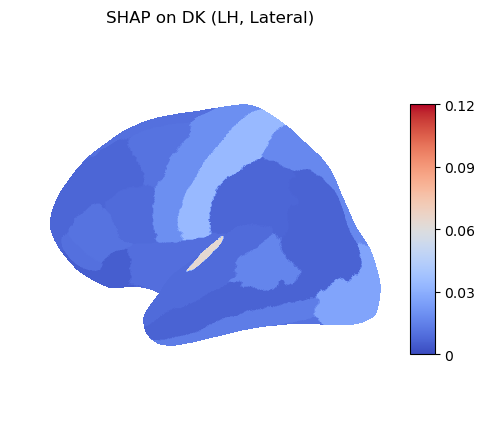

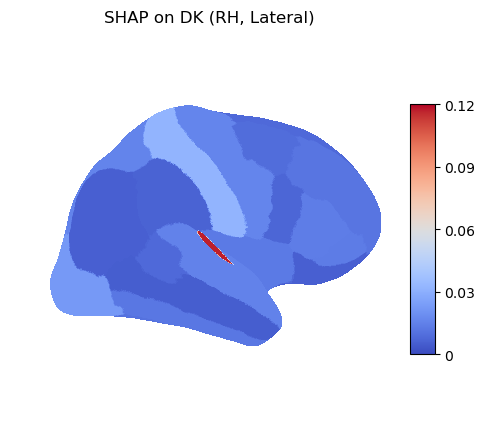

In [23]:
# Define the color map and threshold for visualization
# You can adjust these parameters as needed

cmap = 'coolwarm'
threshold = 0.01
# Use the same contrast for both hemispheres for better comparison
vmin = 0
vmax = 0.12

plotting.plot_surf_stat_map(lh_mesh_path, lh_texture, hemi='left', title='SHAP on DK (LH, Lateral)', view='lateral', cmap=cmap, vmin=vmin, vmax=vmax)
plotting.plot_surf_stat_map(rh_mesh_path, rh_texture, hemi='right', title='SHAP on DK (RH, Lateral)', view='lateral', cmap=cmap, vmin=vmin, vmax=vmax)
plotting.show()

C:\Users\22679\AppData\Local\Temp\ipykernel_13528\1797812686.py:1: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(lh_mesh_path, lh_texture, hemi='left', title='SHAP on DK (LH, Medial)', view='medial', cmap=cmap, vmin=vmin, vmax=vmax)
C:\Users\22679\AppData\Local\Temp\ipykernel_13528\1797812686.py:2: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(rh_mesh_path, rh_texture, hemi='right', title='SHAP on DK (RH, Medial)', view='medial', cmap=cmap, vmin=vmin, vmax=vmax)


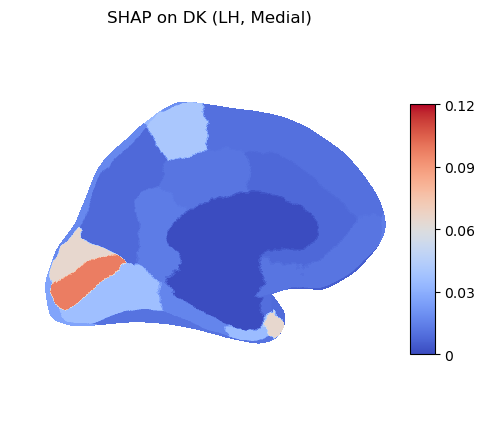

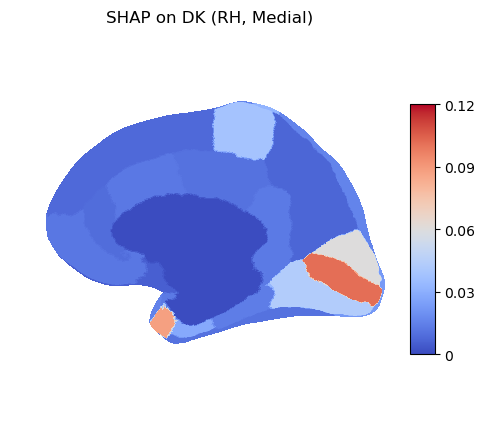

In [24]:
plotting.plot_surf_stat_map(lh_mesh_path, lh_texture, hemi='left', title='SHAP on DK (LH, Medial)', view='medial', cmap=cmap, vmin=vmin, vmax=vmax)
plotting.plot_surf_stat_map(rh_mesh_path, rh_texture, hemi='right', title='SHAP on DK (RH, Medial)', view='medial', cmap=cmap, vmin=vmin, vmax=vmax)
plotting.show()

C:\Users\22679\AppData\Local\Temp\ipykernel_13528\1670682047.py:1: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(lh_mesh_path, lh_texture, hemi='left', title='SHAP on DK (LH, dorsal)', view='dorsal', cmap=cmap, vmin=vmin, vmax=vmax)
C:\Users\22679\AppData\Local\Temp\ipykernel_13528\1670682047.py:2: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(rh_mesh_path, rh_texture, hemi='right', title='SHAP on DK (RH, dorsal)', view='dorsal', cmap=cmap, vmin=vmin, vmax=vmax)


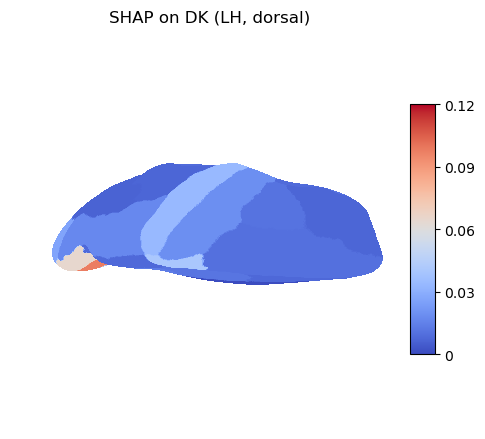

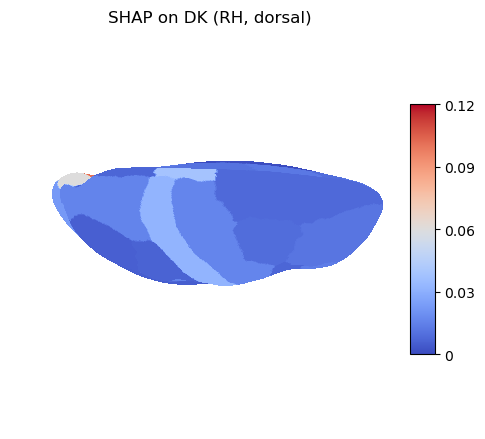

In [25]:
plotting.plot_surf_stat_map(lh_mesh_path, lh_texture, hemi='left', title='SHAP on DK (LH, dorsal)', view='dorsal', cmap=cmap, vmin=vmin, vmax=vmax)
plotting.plot_surf_stat_map(rh_mesh_path, rh_texture, hemi='right', title='SHAP on DK (RH, dorsal)', view='dorsal', cmap=cmap, vmin=vmin, vmax=vmax)
plotting.show()

C:\Users\22679\AppData\Local\Temp\ipykernel_13528\1718732261.py:1: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(lh_mesh_path, lh_texture, hemi='left', title='SHAP on DK (LH, ventral)', view='ventral', cmap=cmap, vmin=vmin, vmax=vmax)
C:\Users\22679\AppData\Local\Temp\ipykernel_13528\1718732261.py:2: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(rh_mesh_path, rh_texture, hemi='right', title='SHAP on DK (RH, ventral)', view='ventral', cmap=cmap, vmin=vmin, vmax=vmax)


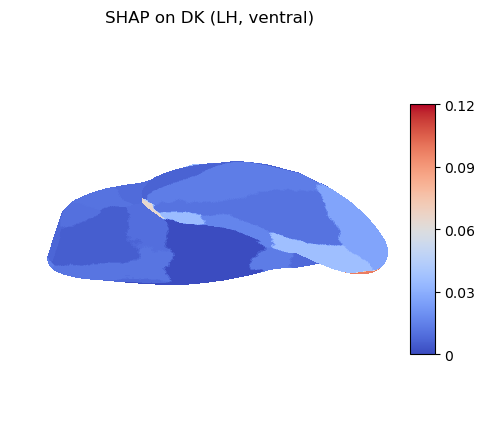

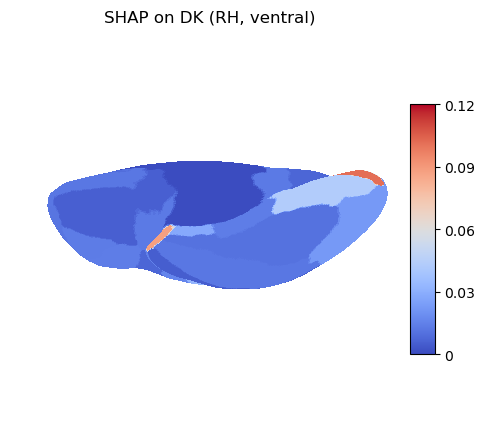

In [26]:
plotting.plot_surf_stat_map(lh_mesh_path, lh_texture, hemi='left', title='SHAP on DK (LH, ventral)', view='ventral', cmap=cmap, vmin=vmin, vmax=vmax)
plotting.plot_surf_stat_map(rh_mesh_path, rh_texture, hemi='right', title='SHAP on DK (RH, ventral)', view='ventral', cmap=cmap, vmin=vmin, vmax=vmax)
plotting.show()

C:\Users\22679\AppData\Local\Temp\ipykernel_13528\1553273915.py:1: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(lh_mesh_path, lh_texture, hemi='left', title='SHAP on DK (LH, anterior)', view='anterior', cmap=cmap, vmin=vmin, vmax=vmax)
C:\Users\22679\AppData\Local\Temp\ipykernel_13528\1553273915.py:2: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(rh_mesh_path, rh_texture, hemi='right', title='SHAP on DK (RH, anterior)', view='anterior', cmap=cmap, vmin=vmin, vmax=vmax)


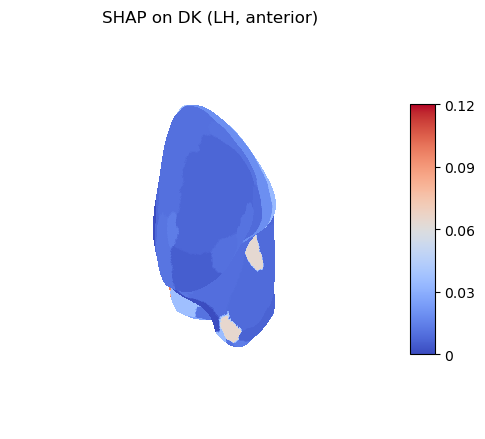

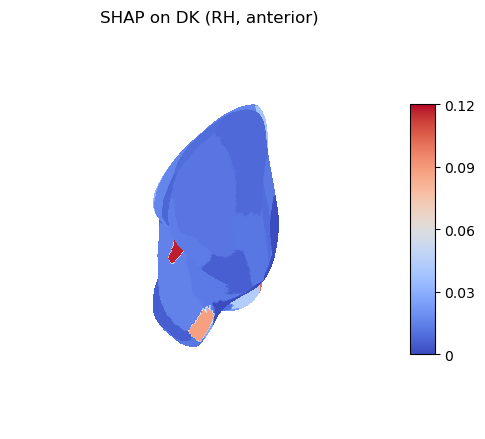

In [27]:
plotting.plot_surf_stat_map(lh_mesh_path, lh_texture, hemi='left', title='SHAP on DK (LH, anterior)', view='anterior', cmap=cmap, vmin=vmin, vmax=vmax)
plotting.plot_surf_stat_map(rh_mesh_path, rh_texture, hemi='right', title='SHAP on DK (RH, anterior)', view='anterior', cmap=cmap, vmin=vmin, vmax=vmax)
plotting.show()

C:\Users\22679\AppData\Local\Temp\ipykernel_13528\1115054463.py:1: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(lh_mesh_path, lh_texture, hemi='left', title='SHAP on DK (LH, posterior)', view='posterior', cmap=cmap, vmin=vmin, vmax=vmax)
C:\Users\22679\AppData\Local\Temp\ipykernel_13528\1115054463.py:2: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(rh_mesh_path, rh_texture, hemi='right', title='SHAP on DK (RH, posterior)', view='posterior', cmap=cmap, vmin=vmin, vmax=vmax)


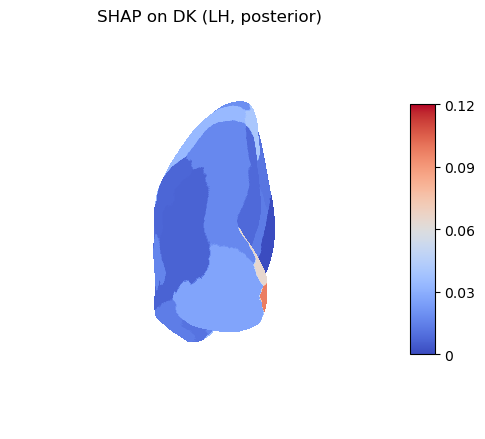

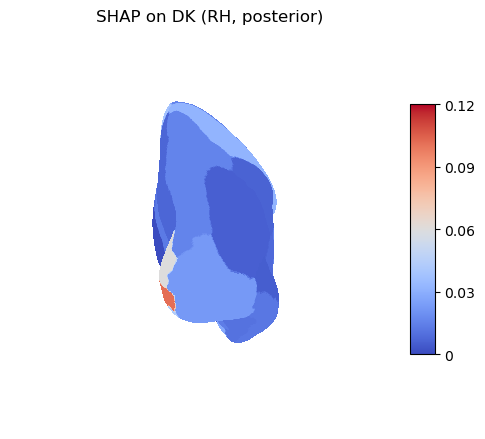

In [28]:
plotting.plot_surf_stat_map(lh_mesh_path, lh_texture, hemi='left', title='SHAP on DK (LH, posterior)', view='posterior', cmap=cmap, vmin=vmin, vmax=vmax)
plotting.plot_surf_stat_map(rh_mesh_path, rh_texture, hemi='right', title='SHAP on DK (RH, posterior)', view='posterior', cmap=cmap, vmin=vmin, vmax=vmax)
plotting.show()